# PSI HDF Data

Load and inspect the two PSI HDF5 files in this folder.

In [7]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Folder containing the PSI HDF files. The fallback lets the cell run from the repo root.
data_dir = Path('.')
if not any(data_dir.glob('*.hdf')):
    data_dir = Path('geometry_optimization/PSI_instrument/data_from_PSI')

hdf_files = sorted(data_dir.glob('*.hdf'))
if not hdf_files:
    raise FileNotFoundError(f'No .hdf files found in {data_dir.resolve()}')

print(f'Data directory: {data_dir.resolve()}')
print(f'HDF files: {len(hdf_files)}')
for path in hdf_files:
    print(f'  {path.name} ({path.stat().st_size / 1024**2:.2f} MiB)')


Data directory: /Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/data_from_PSI
HDF files: 2
  Vanadiumscan_s2t_3p2meV.hdf (2.69 MiB)
  Vanadiumscan_s2t_5meV.hdf (2.64 MiB)


In [8]:
def decode_hdf_value(value):
    arr = np.asarray(value)
    if arr.shape == ():
        item = arr.item()
    elif arr.size == 1:
        item = arr.reshape(-1)[0]
    else:
        return arr

    if isinstance(item, bytes):
        return item.decode('utf-8', errors='replace')
    return item


def read_dataset(file_handle, dataset_path):
    return decode_hdf_value(file_handle[dataset_path][()])


def hdf_tree_rows(path, max_rows=120):
    rows = []
    with h5py.File(path, 'r') as handle:
        def visitor(name, obj):
            kind = 'group' if isinstance(obj, h5py.Group) else 'dataset'
            row = {'file': path.name, 'path': name or '/', 'kind': kind}
            if isinstance(obj, h5py.Dataset):
                row['shape'] = obj.shape
                row['dtype'] = str(obj.dtype)
            else:
                row['shape'] = ''
                row['dtype'] = ''
            rows.append(row)
        handle.visititems(visitor)
    return rows[:max_rows]


def summarize_file(path):
    with h5py.File(path, 'r') as handle:
        detector_data = handle['entry/CAMEA/detector/data']
        total_counts = handle['entry/CAMEA/detector/total_counts'][()]
        summed_counts = handle['entry/CAMEA/detector/summed_counts'][()]
        monitor_2 = handle['entry/monitor_2/data'][()]
        control = handle['entry/control/data'][()]
        return {
            'file': path.name,
            'title': read_dataset(handle, 'entry/title'),
            'proposal_title': read_dataset(handle, 'entry/proposal_title'),
            'scancommand': read_dataset(handle, 'entry/scancommand'),
            'scanvars': read_dataset(handle, 'entry/scanvars'),
            'instrument': read_dataset(handle, 'entry/instrument'),
            'monochromator_energy': read_dataset(handle, 'entry/CAMEA/monochromator/energy'),
            'nominal_analyzer_energy': float(read_dataset(handle, 'entry/CAMEA/analyzer/nominal_energy')),
            'detector_shape': detector_data.shape,
            'scan_points': int(detector_data.shape[0]),
            'total_detector_counts': float(np.nansum(total_counts)),
            'total_summed_counts': float(np.nansum(summed_counts)),
            'total_monitor_2': float(np.nansum(monitor_2)),
            'control_min': float(np.nanmin(control)),
            'control_max': float(np.nanmax(control)),
        }


summary = pd.DataFrame([summarize_file(path) for path in hdf_files])
display(summary)


,file,title,proposal_title,scancommand,scanvars,instrument,monochromator_energy,nominal_analyzer_energy,detector_shape,scan_points,total_detector_counts,total_summed_counts,total_monitor_2,control_min,control_max
0,Vanadiumscan_s2t_3p2meV.hdf,s2t scan of Vanadium 3.2 meV,s2t scan of Vanadium 3.2 meV,"maw(ei,5)\nExp.title='s2t scan of Vanadium 5 m...","s2t,",CAMEA,"[3.2002804, 3.2002804]",4.986954,"(153, 1024, 104)",153,9984677.0,496.0,30600000.0,108507.0,110647.0
1,Vanadiumscan_s2t_5meV.hdf,s2t scan of Vanadium 5 meV,s2t scan of Vanadium 5 meV,"maw(ei,5)\nExp.title='s2t scan of Vanadium 5 m...","s2t,",CAMEA,"[5.000545, 5.000545]",4.986954,"(153, 1024, 104)",153,9937408.0,114635.0,30600000.0,104557.0,106640.0


In [9]:
# Compact internal structure listing.
tree = pd.DataFrame([row for path in hdf_files for row in hdf_tree_rows(path)])
display(tree)


,file,path,kind,shape,dtype
0,Vanadiumscan_s2t_3p2meV.hdf,entry,group,,
1,Vanadiumscan_s2t_3p2meV.hdf,entry/CAMEA,group,,
2,Vanadiumscan_s2t_3p2meV.hdf,entry/CAMEA/analyzer,group,,
3,Vanadiumscan_s2t_3p2meV.hdf,entry/CAMEA/analyzer/analyzer_selection,dataset,"(1,)",int32
4,Vanadiumscan_s2t_3p2meV.hdf,entry/CAMEA/analyzer/d_spacing,dataset,"(1,)",float32
...,...,...,...,...,...
227,Vanadiumscan_s2t_5meV.hdf,entry/start_time,dataset,"(1,)",|S28
228,Vanadiumscan_s2t_5meV.hdf,entry/title,dataset,"(1,)",|S27
229,Vanadiumscan_s2t_5meV.hdf,entry/user,group,,
230,Vanadiumscan_s2t_5meV.hdf,entry/user/email,dataset,"(1,)",|S1


In [10]:
# Load the main arrays into memory for plotting.
psi_data = {}
for path in hdf_files:
    with h5py.File(path, 'r') as handle:
        psi_data[path.name] = {
            'detector_data': handle['entry/CAMEA/detector/data'][()],
            'summed_counts': handle['entry/CAMEA/detector/summed_counts'][()],
            'total_counts': handle['entry/CAMEA/detector/total_counts'][()],
            'monitor_2': handle['entry/monitor_2/data'][()],
            'control': handle['entry/control/data'][()],
            'absolute_time': handle['entry/control/absolute_time'][()],
            'analyzer_angle_raw': handle['entry/CAMEA/analyzer/polar_angle_raw'][()],
        }

for name, data in psi_data.items():
    print(name)
    for key, value in data.items():
        print(f'  {key:<20} shape={np.shape(value)} dtype={np.asarray(value).dtype}')


Vanadiumscan_s2t_3p2meV.hdf
  detector_data        shape=(153, 1024, 104) dtype=float64
  summed_counts        shape=(153,) dtype=float64
  total_counts         shape=(153,) dtype=float64
  monitor_2            shape=(153,) dtype=float64
  control              shape=(77,) dtype=float32
  absolute_time        shape=(77,) dtype=float64
  analyzer_angle_raw   shape=(77,) dtype=float32
Vanadiumscan_s2t_5meV.hdf
  detector_data        shape=(153, 1024, 104) dtype=float64
  summed_counts        shape=(153,) dtype=float64
  total_counts         shape=(153,) dtype=float64
  monitor_2            shape=(153,) dtype=float64
  control              shape=(77,) dtype=float32
  absolute_time        shape=(77,) dtype=float64
  analyzer_angle_raw   shape=(77,) dtype=float32


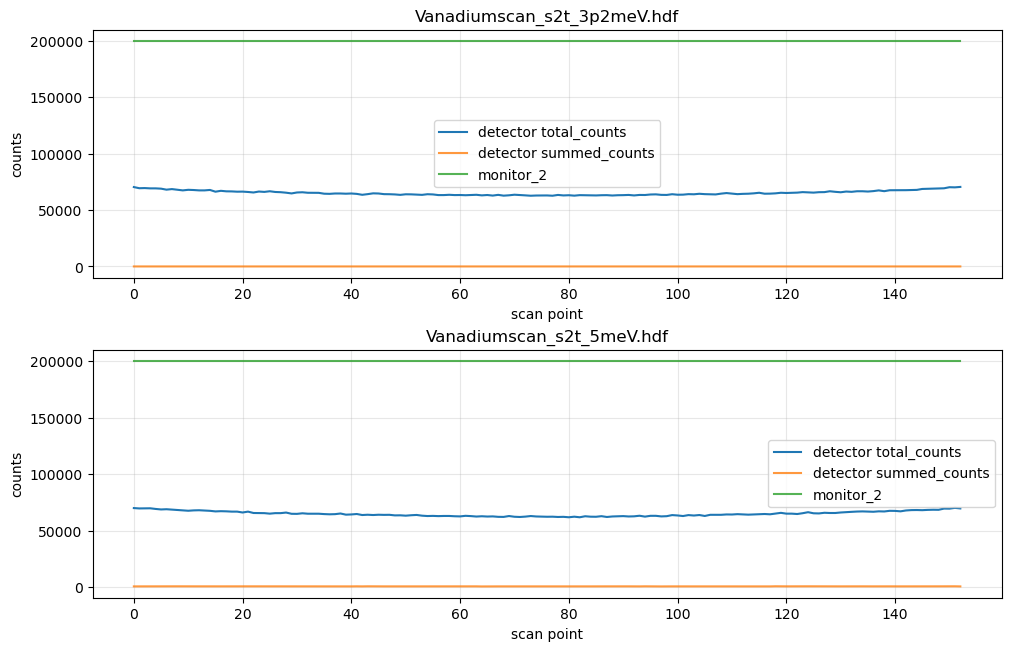

In [11]:
# Scan-wise counts and monitor traces.
fig, axes = plt.subplots(len(psi_data), 1, figsize=(10, 3.2 * len(psi_data)), constrained_layout=True)
axes = np.atleast_1d(axes)

for ax, (name, data) in zip(axes, psi_data.items()):
    x = np.arange(data['total_counts'].size)
    ax.plot(x, data['total_counts'], label='detector total_counts')
    ax.plot(x, data['summed_counts'], label='detector summed_counts', alpha=0.8)
    ax.plot(x, data['monitor_2'], label='monitor_2', alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('scan point')
    ax.set_ylabel('counts')
    ax.grid(alpha=0.3)
    ax.legend(loc='best')

plt.show()


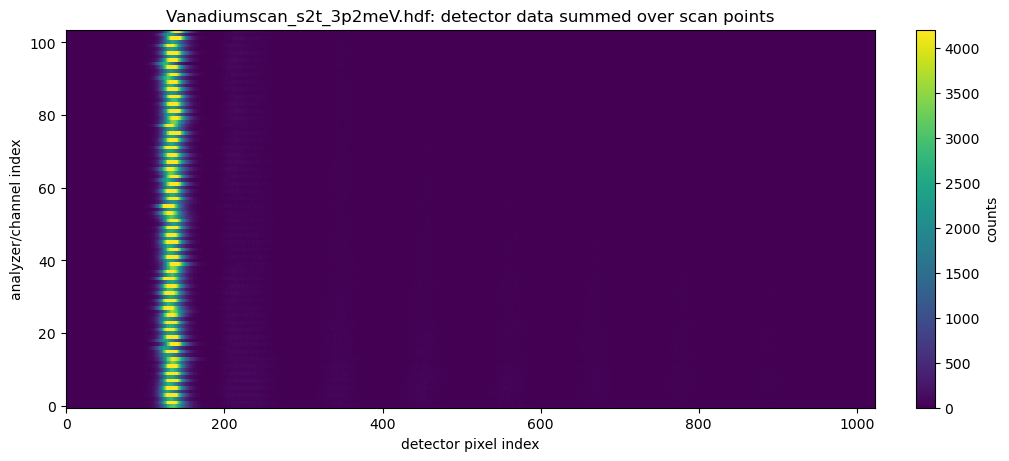

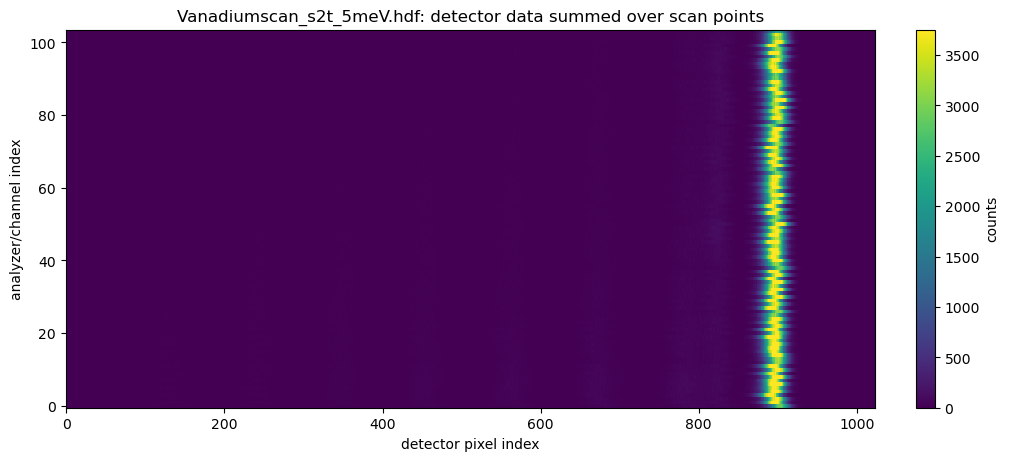

In [12]:
# Detector images integrated over scan points.
for name, data in psi_data.items():
    image = np.nansum(data['detector_data'], axis=0)
    vmin, vmax = np.nanpercentile(image, [1, 99.5])

    fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
    im = ax.imshow(image.T, origin='lower', aspect='auto', interpolation='nearest', vmin=vmin, vmax=vmax)
    ax.set_title(f'{name}: detector data summed over scan points')
    ax.set_xlabel('detector pixel index')
    ax.set_ylabel('analyzer/channel index')
    fig.colorbar(im, ax=ax, label='counts')
    plt.show()


## First-pass Angular Reduction

This maps detector counts to a scattering-angle axis using the CAMEA calibration tables. It is intended as a diagnostic comparison to the simulation angular monitor, not a full PSI reduction pipeline.

In [13]:
# First-pass settings for reducing the raw detector data to scattering angle.
calibration_group = 'calib8'          # calib1, calib3, calib5, calib8; higher number gives finer energy segmentation
elastic_energy_tolerance_meV = 0.08   # select calibration entries with final_energy close to Ei
angle_bin_width_deg = 0.5
angle_range_deg = (-120.0, 0.0)
normalize_by_monitor = True

# PSI CAMEA arm in these files is centered near -75 deg. This is the same 60 deg wide window,
# but only for the measured negative arm.
psi_window_center_deg = -75.0
psi_window_width_deg = 60.0


In [14]:
def reconstruct_s2t_axis(n_scan):
    # The HDF scancommand contains two scans:
    # scan(s2t,-40,-0.5,77,m=200000) and scan(s2t,-77.75,0.5,76,m=200000)
    # The detector arrays have 153 scan points, i.e. these two scans concatenated.
    first = -40.0 + (-0.5) * np.arange(77)
    second = -77.75 + 0.5 * np.arange(76)
    axis = np.concatenate([first, second])
    if axis.size != n_scan:
        raise ValueError(f'Expected {axis.size} scan points from scancommand, got detector axis length {n_scan}')
    return axis


def incident_energy_meV(handle):
    energy = np.asarray(handle['entry/CAMEA/monochromator/energy'][()], dtype=float).reshape(-1)
    return float(np.nanmean(energy))


def reduce_hdf_to_angle(path, calib='calib8', energy_tolerance_meV=0.08, bin_width_deg=0.5, angle_range=(-120, 0)):
    with h5py.File(path, 'r') as handle:
        detector = handle['entry/CAMEA/detector/data'][()]
        monitor = handle['entry/monitor_2/data'][()]
        ei = incident_energy_meV(handle)

        group = handle[f'entry/CAMEA/{calib}']
        a4offset = group['a4offset'][()]
        final_energy = group['final_energy'][()]
        boundaries = group['boundaries'][()]

    n_scan, n_pixel, n_channel = detector.shape
    s2t = reconstruct_s2t_axis(n_scan)

    if a4offset.size % n_channel != 0:
        raise ValueError(f'{calib} entries={a4offset.size} cannot be reshaped by n_channel={n_channel}')
    n_segments = a4offset.size // n_channel

    a4offset = a4offset.reshape(n_channel, n_segments)
    final_energy = final_energy.reshape(n_channel, n_segments)
    boundaries = boundaries.reshape(n_channel, n_segments, 2)

    selected = np.abs(final_energy - ei) <= energy_tolerance_meV
    if not np.any(selected):
        raise ValueError(f'No {calib} entries within {energy_tolerance_meV:g} meV of Ei={ei:.4g} meV')

    angles = []
    weights = []
    for channel in range(n_channel):
        for segment in range(n_segments):
            if not selected[channel, segment]:
                continue
            x0, x1 = boundaries[channel, segment]
            x0 = int(max(0, min(n_pixel, x0)))
            x1 = int(max(0, min(n_pixel, x1)))
            if x1 <= x0:
                continue

            counts = detector[:, x0:x1, channel].sum(axis=1)
            if normalize_by_monitor:
                counts = counts / monitor
            angle = s2t + float(a4offset[channel, segment])
            angles.append(angle)
            weights.append(counts)

    angles = np.concatenate(angles)
    weights = np.concatenate(weights)
    finite = np.isfinite(angles) & np.isfinite(weights)
    angles = angles[finite]
    weights = weights[finite]

    bin_edges = np.arange(angle_range[0], angle_range[1] + bin_width_deg, bin_width_deg)
    summed, _ = np.histogram(angles, bins=bin_edges, weights=weights)
    occupancy, _ = np.histogram(angles, bins=bin_edges)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    mean = np.divide(summed, occupancy, out=np.full_like(summed, np.nan, dtype=float), where=occupancy > 0)

    window_mask = np.abs(centers - psi_window_center_deg) <= psi_window_width_deg / 2.0
    return {
        'file': path.name,
        'Ei_meV': ei,
        'calibration': calib,
        'selected_calibration_entries': int(np.count_nonzero(selected)),
        'angles': angles,
        'weights': weights,
        'bin_centers': centers,
        'bin_sum': summed,
        'bin_occupancy': occupancy,
        'bin_mean': mean,
        'window_sum': float(np.nansum(summed[window_mask])),
        'window_mean': float(np.nanmean(mean[window_mask])),
    }


angular_reductions = [
    reduce_hdf_to_angle(
        path,
        calib=calibration_group,
        energy_tolerance_meV=elastic_energy_tolerance_meV,
        bin_width_deg=angle_bin_width_deg,
        angle_range=angle_range_deg,
    )
    for path in hdf_files
]

angular_summary = pd.DataFrame([
    {
        'file': item['file'],
        'Ei_meV': item['Ei_meV'],
        'calibration': item['calibration'],
        'selected_calibration_entries': item['selected_calibration_entries'],
        'window_center_deg': psi_window_center_deg,
        'window_width_deg': psi_window_width_deg,
        'window_sum': item['window_sum'],
        'window_mean': item['window_mean'],
    }
    for item in angular_reductions
])
display(angular_summary)


,file,Ei_meV,calibration,selected_calibration_entries,window_center_deg,window_width_deg,window_sum,window_mean
0,Vanadiumscan_s2t_3p2meV.hdf,3.200280,calib8,608,-75.0,60.0,31.986875,0.000484
1,Vanadiumscan_s2t_5meV.hdf,5.000545,calib8,301,-75.0,60.0,25.876625,0.000773


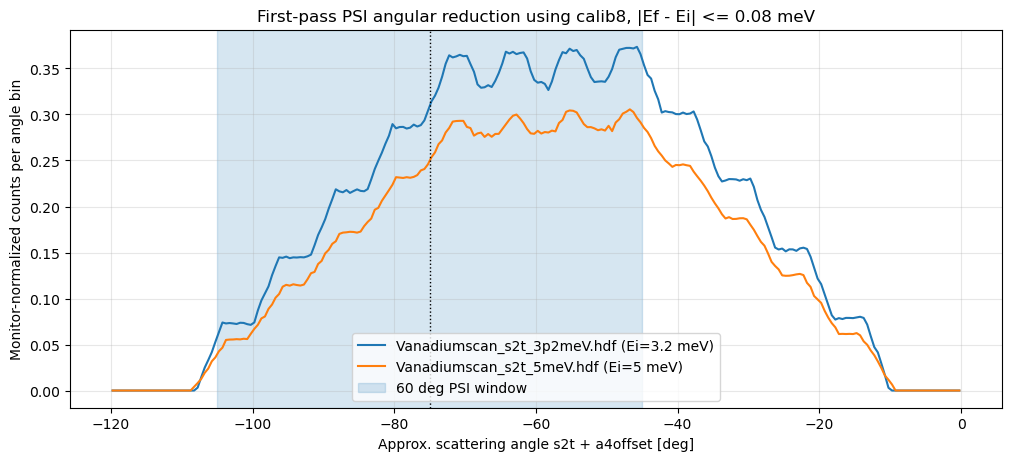

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
for item in angular_reductions:
    ax.plot(item['bin_centers'], item['bin_sum'], label=f"{item['file']} (Ei={item['Ei_meV']:.3g} meV)")

ax.axvspan(
    psi_window_center_deg - psi_window_width_deg / 2,
    psi_window_center_deg + psi_window_width_deg / 2,
    alpha=0.18,
    color='tab:blue',
    label=f'{psi_window_width_deg:g} deg PSI window',
)
ax.axvline(psi_window_center_deg, color='black', linestyle=':', linewidth=1.0)
ax.set_title(
    f'First-pass PSI angular reduction using {calibration_group}, '
    f'|Ef - Ei| <= {elastic_energy_tolerance_meV:g} meV'
)
ax.set_xlabel('Approx. scattering angle s2t + a4offset [deg]')
ax.set_ylabel('Monitor-normalized counts per angle bin' if normalize_by_monitor else 'Counts per angle bin')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()


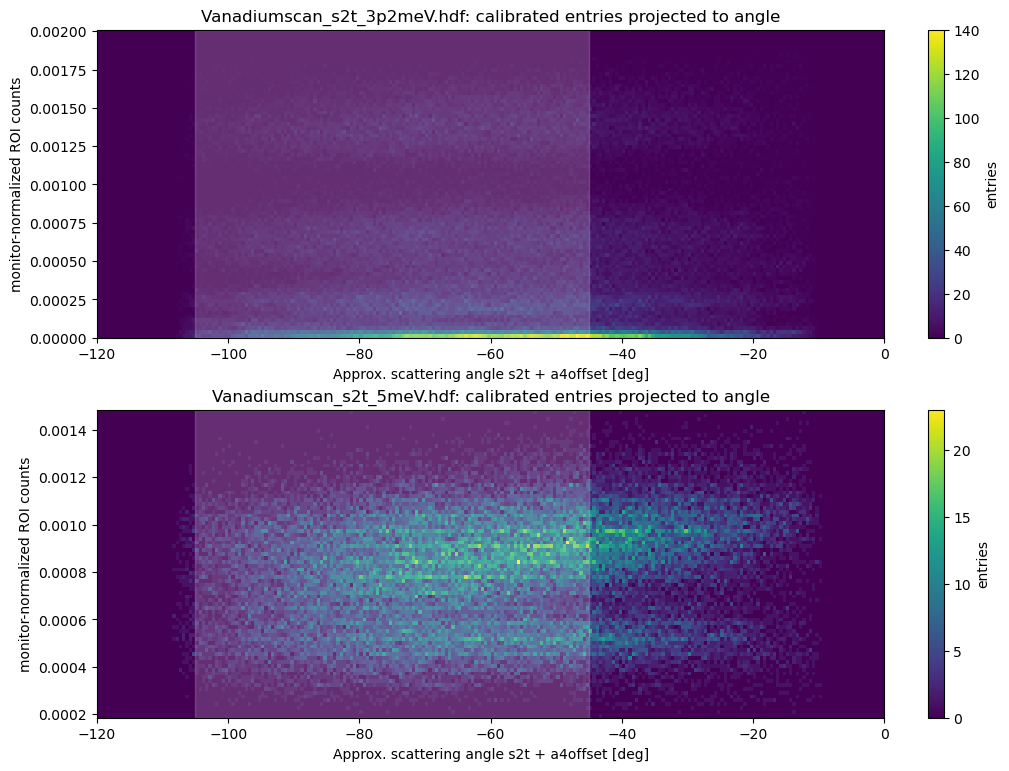

In [16]:
fig, axes = plt.subplots(len(angular_reductions), 1, figsize=(10, 3.8 * len(angular_reductions)), constrained_layout=True)
axes = np.atleast_1d(axes)

for ax, item in zip(axes, angular_reductions):
    h = ax.hist2d(
        item['angles'],
        item['weights'],
        bins=[np.arange(angle_range_deg[0], angle_range_deg[1] + angle_bin_width_deg, angle_bin_width_deg), 80],
        cmap='viridis',
    )
    ax.axvspan(
        psi_window_center_deg - psi_window_width_deg / 2,
        psi_window_center_deg + psi_window_width_deg / 2,
        alpha=0.18,
        color='white',
    )
    ax.set_title(f"{item['file']}: calibrated entries projected to angle")
    ax.set_xlabel('Approx. scattering angle s2t + a4offset [deg]')
    ax.set_ylabel('monitor-normalized ROI counts' if normalize_by_monitor else 'ROI counts')
    fig.colorbar(h[3], ax=ax, label='entries')

plt.show()
